# Station time series and storm index

This shows how wind and snow water equivalent from the weather stations are compared with $\gamma_{snow}$ for each date pair. 

In [55]:
import numpy as np
import xarray as xr
import pandas as pd
import rioxarray  
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from seaborn import set_theme
set_theme()

import sys
import os
from pathlib import Path

# import from this repo 
project_root = str(Path(os.getcwd()).parent)
if project_root not in sys.path:
    sys.path.append(project_root)

%load_ext autoreload
%autoreload 2
from scripts.stations import read_mesowest, read_snotel, event_wind_by_pair

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First, we setup logging to get useful information and error messages. 

In [2]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True 
)

Open the data cubes that were saved by the previous notebook. 

In [6]:
data_dir = "../data/"

nisar_20m = xr.open_zarr(data_dir + 'nisar/zarrs/snow_20m.zarr').isel(pair=slice(1, -2))
nisar_80m = xr.open_zarr(data_dir + 'nisar/zarrs/snow_80m.zarr').isel(pair=slice(1, -2))

The start and end time of each date pair are stored in the cube. 

In [7]:
starts = nisar_80m['start'].values
ends = nisar_80m['end'].values
unique_dates = np.unique(np.concatenate([starts, ends]))

Load the wind speed from the MesoWest stations. The time zone offset needs to match the cubes. 

In [8]:
wind_files = sorted(Path(data_dir + 'stations/mesowest/').glob('*.csv'))
wind_names = {
    'SOSC2': 'schofield_pass',
    'CACNM': 'cinnamon_mtn',
    'CASCP': 'irwins_ridge',
}

wind = read_mesowest(wind_files, wind_names, utc_offset_hours=-7)

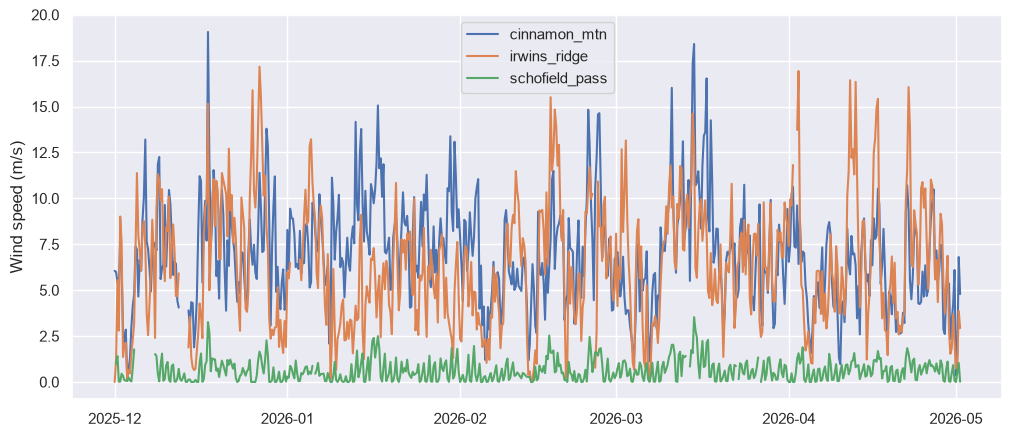

In [9]:
sub = wind.sel(datetime=slice('2025-12-01', '2026-05-01'))
fig, ax = plt.subplots(figsize=(12, 5))
for sid in sub.station_id.values:
    s = sub.sel(station_id=sid).resample(datetime='6h').mean()
    ax.plot(s.datetime, s, label=str(s.station_name.values))
ax.set_ylabel(f"Wind speed ({wind.attrs['units']})")
ax.legend()

Load the snow water equivalent from the SNOTEL stations. 

In [10]:
snotel_files = sorted(Path(data_dir + 'stations/snotel/').glob('*.csv'))
snotel_names = {
    '1141': 'upper_taylor',
    '380':  'butte',
    '1326': 'castle_peak',
    '737':  'schofield_pass',
}

swe = read_snotel(snotel_files, snotel_names, utc_offset_hours=-7)

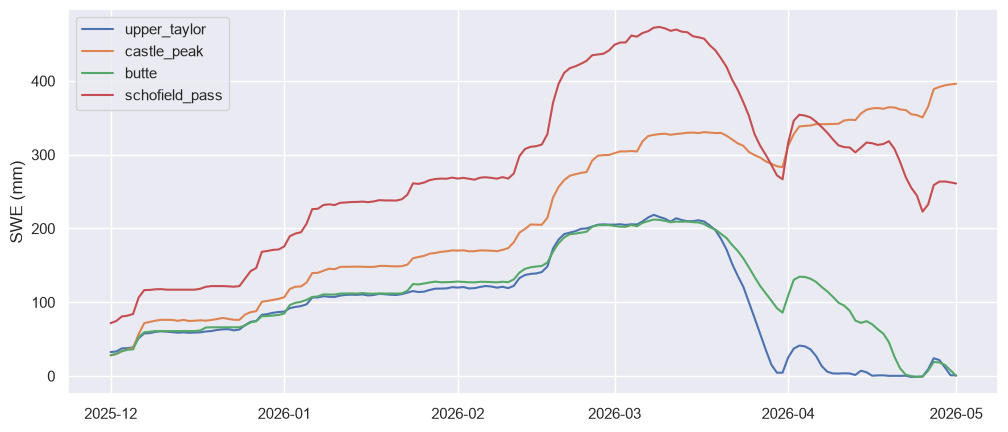

In [11]:
sub = swe['swe'].sel(datetime=slice('2025-12-01', '2026-05-01'))
fig, ax = plt.subplots(figsize=(12, 5))
for sid in sub.station_id.values:
    s = sub.sel(station_id=sid).resample(datetime='1d').mean()
    ax.plot(s.datetime, s, label=str(s.station_name.values))
ax.set_ylabel(f"SWE (mm)")
ax.legend()

Plot SWE and wind together, with the NISAR acquisition dates in orange. 

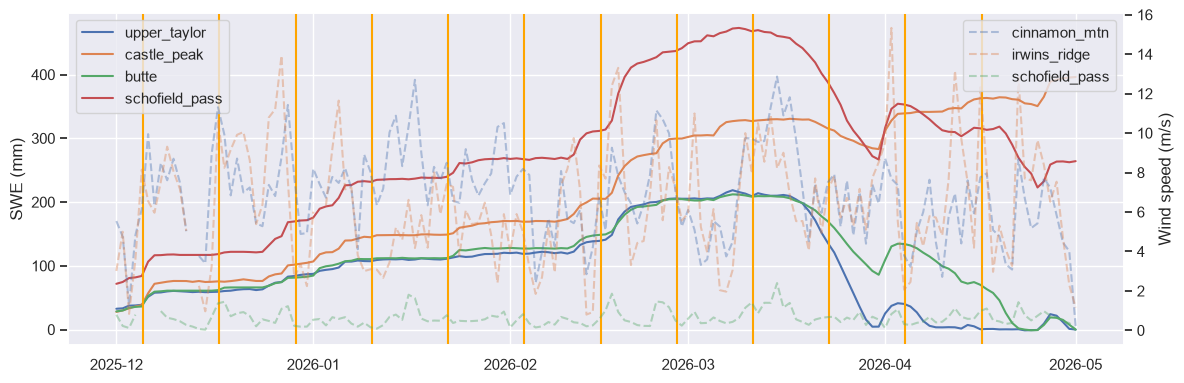

In [12]:
t0 = np.datetime64('2025-12-01')
t1 = np.datetime64('2026-05-01')

swe_plot = swe.sel(datetime=slice(t0, t1)).resample(datetime='1d').mean()
wind_plot = wind.sel(datetime=slice(t0, t1)).resample(datetime='1d').mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax2 = ax.twinx()

for sid in swe_plot.station_id.values:
    station = swe_plot['swe'].sel(station_id=sid)
    ax.plot(station.datetime, station, label=str(station.station_name.values))
ax.set_ylabel('SWE (mm)')
ax.legend()

for sid in wind_plot.station_id.values:
    station = wind_plot.sel(station_id=sid)
    ax2.plot(station.datetime, station, alpha=0.4, linestyle='--', label=str(station.station_name.values))
ax2.set_ylabel('Wind speed (m/s)')
ax2.grid(False)
ax2.legend(loc='upper right')

[ax.axvline(d, c='orange') for d in unique_dates]

plt.tight_layout()
plt.show()

Limit to just the dry snow pairs for this part. 

In [122]:
nisar_20m_dry = nisar_20m.sel(start=slice("2025-12-01", "2026-02-20"))
nisar_80m_dry = nisar_80m.sel(start=slice("2025-12-01", "2026-02-20"))

dry_starts = nisar_80m_dry['start'].values
dry_ends = nisar_80m_dry['end'].values

wind_dry = wind.sel(datetime=slice(dry_starts[0], dry_ends[-1]))
swe_dry = swe.sel(datetime=slice(dry_starts[0], dry_ends[-1]))

Scatter by total SWE accumulation, max 6h SWE accumulation, mean wind, and sum wind-hours. 

In [113]:
wind

<xarray.DataArray 'wind_speed' (station_id: 3, datetime: 4369)> Size: 105kB
array([[6.0525, 5.1175, 5.495 , ..., 4.0625, 6.0275, 5.18  ],
       [0.    , 0.    , 0.    , ..., 2.46  , 2.63  , 2.99  ],
       [   nan,    nan, 0.    , ..., 0.    , 0.    , 0.    ]],
      shape=(3, 4369))
Coordinates:
  * station_id    (station_id) object 24B 'CACNM' 'CASCP' 'SOSC2'
    station_name  (station_id) <U14 168B 'cinnamon_mtn' ... 'schofield_pass'
  * datetime      (datetime) datetime64[us] 35kB 2025-12-01T05:00:00 ... 2026...
Attributes:
    units:             m/s
    long_name:         Wind speed
    utc_offset_hours:  -7

In [138]:
swe_stns = ['schofield_pass']
wind_stns = ['CACNM']

swe_tot, swe_max, wind_mean, wind_hrs, pairs = [], [], [], [], []
for start, end in zip(dry_starts, dry_ends):
    start, end = np.datetime64(start), np.datetime64(end)
    # print(start, end)

    swe_event = swe_dry.sel(station_name=swe_stns, datetime=slice(start, end))
    wind_event = wind_dry.sel(station_id=wind_stns, datetime=slice(start, end))
    swe_event = swe_event.mean(dim='station_id')
    wind_event = wind_event.mean(dim='station_id')

    swe_tot.append(float(np.nansum(swe_event['swe_accum'].where(swe_event['swe_accum'] > 0).values)))
    swe_max.append(float(np.max(swe_event['swe_accum'].resample(datetime='6h').sum().values)))
    wind_mean.append(float(np.nanmean(wind_event.values)))
    wind_hrs.append(float(np.sum(wind_event.values > 0)))
    pairs.append(f"{pd.Timestamp(start):%Y%m%d}_{pd.Timestamp(end):%Y%m%d}")

metrics = xr.Dataset({
    'swe_tot': ('pair', swe_tot),
    'swe_max': ('pair', swe_max),
    'wind_mean': ('pair', wind_mean),
    'wind_hrs': ('pair', wind_hrs)
}, coords={'pair': pairs})
metrics

<xarray.Dataset> Size: 700B
Dimensions:    (pair: 7)
Coordinates:
  * pair       (pair) <U17 476B '20251205_20251217' ... '20260215_20260227'
Data variables:
    swe_tot    (pair) float64 56B 71.12 73.66 101.6 73.66 104.1 114.3 175.3
    swe_max    (pair) float64 56B 12.7 10.16 7.62 5.08 7.62 7.62 17.78
    wind_mean  (pair) float64 56B 7.054 7.893 7.091 8.751 7.988 5.414 7.811
    wind_hrs   (pair) float64 56B 251.0 288.0 288.0 288.0 288.0 276.0 276.0

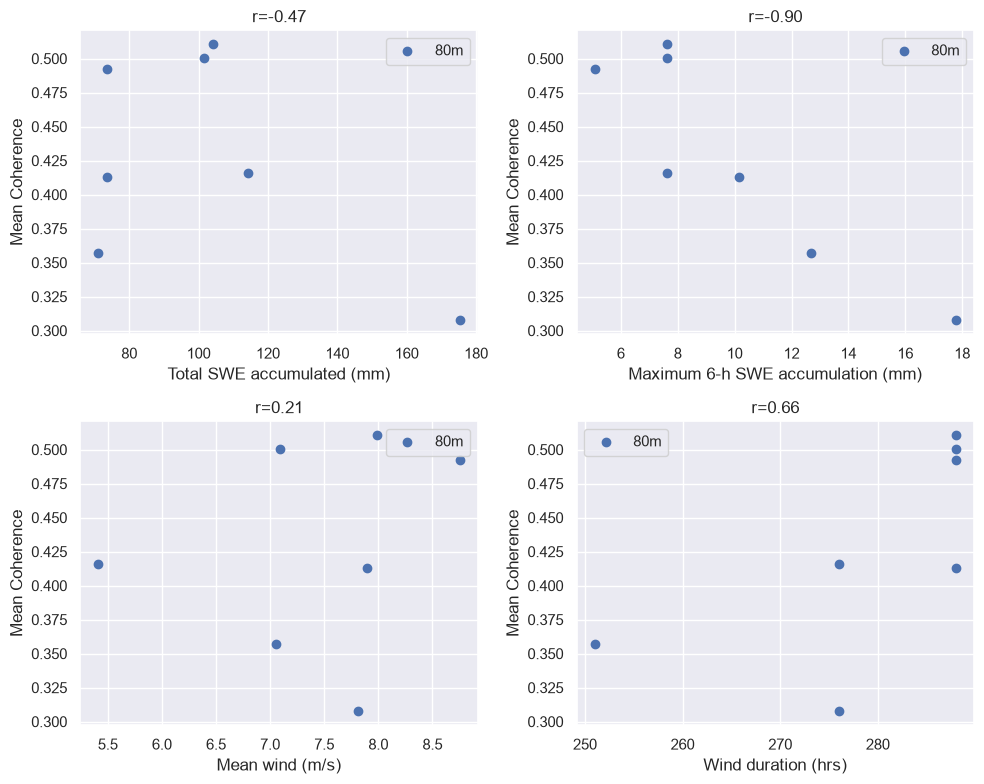

In [141]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

ax[0, 0].scatter(metrics['swe_tot'], nisar_80m_dry['coherence'].mean(dim=['x', 'y']), label='80m')
# ax[0, 0].scatter(metrics['swe_tot'], nisar_20m_dry['coherence'].mean(dim=['x', 'y']), label='20m')
ax[0, 0].set_title('r={:.2f}'.format(np.corrcoef(metrics['swe_tot'], nisar_80m_dry['coherence'].mean(dim=['x', 'y']))[0, 1]))
ax[0, 0].set_xlabel('Total SWE accumulated (mm)')
ax[0, 0].set_ylabel('Mean Coherence')
ax[0, 0].legend()

ax[0, 1].scatter(metrics['swe_max'], nisar_80m_dry['coherence'].mean(dim=['x', 'y']), label='80m')
# ax[0, 1].scatter(metrics['swe_max'], nisar_20m_dry['coherence'].mean(dim=['x', 'y']), label='20m')
ax[0, 1].set_title('r={:.2f}'.format(np.corrcoef(metrics['swe_max'], nisar_80m_dry['coherence'].mean(dim=['x', 'y']))[0, 1]))
ax[0, 1].set_xlabel('Maximum 6-h SWE accumulation (mm)')
ax[0, 1].set_ylabel('Mean Coherence')
ax[0, 1].legend()

ax[1, 0].scatter(metrics['wind_mean'], nisar_80m_dry['coherence'].mean(dim=['x', 'y']), label='80m')
# ax[1, 0].scatter(metrics['wind_mean'], nisar_20m_dry['coherence'].mean(dim=['x', 'y']), label='20m')
ax[1, 0].set_title('r={:.2f}'.format(np.corrcoef(metrics['wind_mean'], nisar_80m_dry['coherence'].mean(dim=['x', 'y']))[0, 1]))
ax[1, 0].set_xlabel('Mean wind (m/s)')
ax[1, 0].set_ylabel('Mean Coherence')
ax[1, 0].legend()

ax[1, 1].scatter(metrics['wind_hrs'], nisar_80m_dry['coherence'].mean(dim=['x', 'y']), label='80m')
# ax[1, 1].scatter(metrics['wind_hrs'], nisar_20m_dry['coherence'].mean(dim=['x', 'y']), label='20m')
ax[1, 1].set_title('r={:.2f}'.format(np.corrcoef(metrics['wind_hrs'], nisar_80m_dry['coherence'].mean(dim=['x', 'y']))[0, 1]))
ax[1, 1].set_xlabel('Wind duration (hrs)')
ax[1, 1].set_ylabel('Mean Coherence')
ax[1, 1].legend()

plt.tight_layout()
plt.show()

Combine daily wind and SWE accumulation into a storm index. 

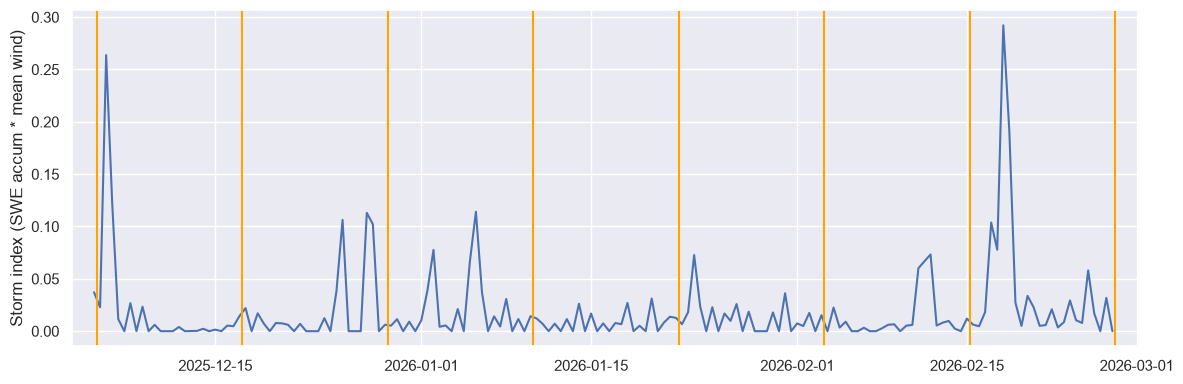

In [150]:
wind_daily = wind_dry.resample(datetime='12h').mean()
swe_daily = swe_dry['swe_accum'].resample(datetime='12h').sum() 

storm_index = (wind_daily.mean(dim=['station_id']) / wind_daily.max() ) * (swe_daily.where(swe_daily > 1, 0).mean(dim=['station_id']) / swe_daily.max())

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(storm_index.datetime, storm_index)
ax.set_ylabel('Storm index (SWE accum * mean wind)')

[ax.axvline(d, c='orange') for d in unique_dates]

ax.set_xlim(start_date - pd.Timedelta(days=2), end_date + pd.Timedelta(days=2))

plt.tight_layout()
plt.show()

Average the storm index over each date pair. 

In [151]:
storm_by_pair = xr.DataArray(
    [storm_index.sel(datetime=slice(s, e)).sum().values.item() for s, e in zip(starts, ends)],
    dims='pair', coords={'pair': nisar_80m['pair'].values}, name='storm_index',
)
storm_by_pair

<xarray.DataArray 'storm_index' (pair: 11)> Size: 88B
array([0.50939845, 0.45352784, 0.47624555, 0.20089681, 0.31432975,
       0.30304918, 0.98081156, 0.        , 0.        , 0.        ,
       0.        ])
Coordinates:
  * pair     (pair) <U17 748B '20251205_20251217' ... '20260404_20260416'

Compare the storm index with the mean $\gamma_{snow}$ for each pair. 

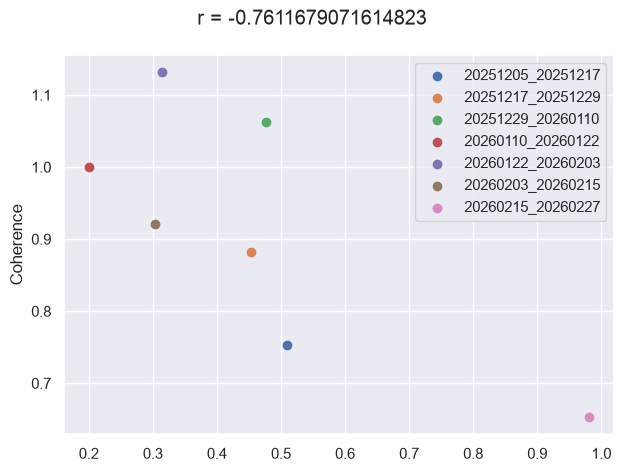

In [152]:
# l = ['20251205_20251217', '20251217_20251229', '20251229_20260110', '20260110_20260122',
#  '20260122_20260203', '20260203_20260215', '20260215_20260227']
gamma_snow_mean = nisar_80m_dry['gamma_snow'].mean(dim=['x', 'y'])

fig, ax = plt.subplots()

for k in l: 
    ax.scatter(storm_by_pair.sel(pair=k), gamma_snow_mean.sel(pair=k), label=k)
ax.set_ylabel('Coherence')
ax.legend()

mat = np.corrcoef(storm_by_pair.sel(pair=gamma_snow_mean.pair.values).values, gamma_snow_mean.values.squeeze())
r = mat[0, 1]

fig.suptitle(f'r = {r}')

plt.tight_layout()
plt.show()

Next, find the mean wind speed during the snow accumulation events in each date pair. An event is any 6 hour period with more than 6 mm of SWE accumulation, plus the following 24 hours. 

In [167]:
threshold = 6  # mm
freq = '12h'

swe_stns = ['schofield_pass']
wind_stns = ['CACNM']

snow_wind_mps = event_wind_by_pair(swe_dry.sel(station_name=swe_stns)['swe_accum'], 
                                   wind_dry.sel(station_id=wind_stns), 
                                   starts, ends, 
                                   threshold, freq=freq)

In [168]:
snow_wind_mps * metrics['swe_max']

<xarray.DataArray (pair: 7)> Size: 56B
array([103.24372396,  80.64764583,  54.91099   ,   0.        ,
        55.83184583,  39.02949568, 150.5145471 ])
Coordinates:
  * pair     (pair) <U17 476B '20251205_20251217' ... '20260215_20260227'

Plot coherence against the event wind speed for both grids. 

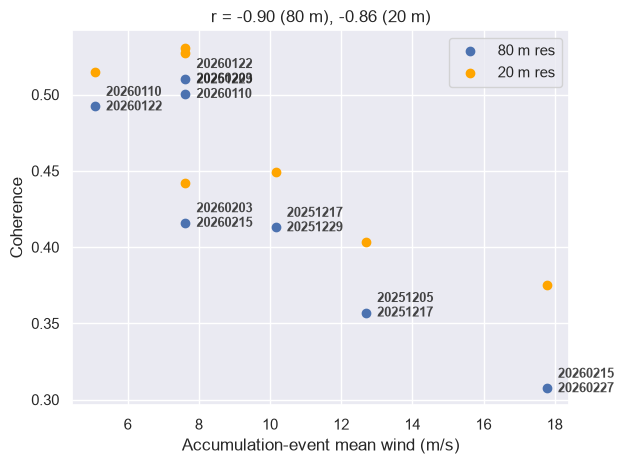

In [172]:
wind_80m = snow_wind_mps.sel(pair=nisar_80m_dry['pair'].values) * metrics['swe_max']
wind_20m = snow_wind_mps.sel(pair=nisar_20m_dry['pair'].values) * metrics['swe_max']

wind_80m = metrics['swe_max']
wind_20m = metrics['swe_max']

coh_80m = nisar_80m_dry['coherence'].mean(dim=['x', 'y'])
coh_20m = nisar_20m_dry['coherence'].mean(dim=['x', 'y'])

fig, ax = plt.subplots()

ax.scatter(wind_80m, coh_80m, label='80 m res')
ax.scatter(wind_20m, coh_20m, c='orange', label='20 m res')

ax.set_title(f'r = {np.corrcoef(wind_80m, coh_80m)[0, 1]:.2f} (80 m), {np.corrcoef(wind_20m, coh_20m)[0, 1]:.2f} (20 m)')

ax.set_ylabel('Coherence')
ax.set_xlabel('Accumulation-event mean wind (m/s)')
ax.legend()

for pair_label in nisar_80m_dry['pair'].values:
    ax.annotate(
        "\n".join(pair_label.split('_')),
        (wind_80m.sel(pair=pair_label), coh_80m.sel(pair=pair_label)),
        textcoords="offset points",
        xytext=(8, 5),
        ha="left",
        va="center",
        fontsize=9,
        fontweight="semibold",
        alpha=0.85,
        zorder=5,
    )

plt.tight_layout()
plt.show()

Plot the difference between the two grids against the event wind speed. 

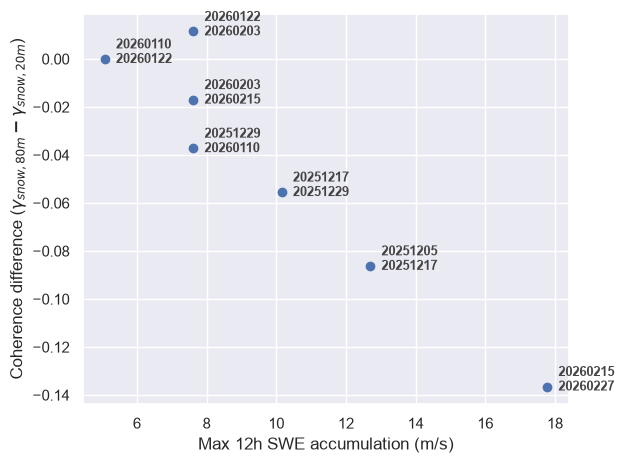

In [177]:
nisar_20m_reproj = nisar_20m_dry['gamma_snow'].rio.reproject_match(nisar_80m, resampling=Resampling.bilinear)
coherence_diff = (nisar_80m_dry['gamma_snow'] - nisar_20m_reproj).mean(dim=['x', 'y'])
wind_diff = snow_wind_mps.sel(pair=coherence_diff['pair'].values)
wind_diff = metrics['swe_max']

fig, ax = plt.subplots()

ax.scatter(wind_diff, coherence_diff)

ax.set_ylabel('Coherence difference ($\gamma_{snow, 80m} - \gamma_{snow, 20m}$)')
ax.set_xlabel(f'Max {freq} SWE accumulation (m/s)')

for pair_label in coherence_diff['pair'].values:
    ax.annotate(
        "\n".join(pair_label.split('_')),
        (wind_diff.sel(pair=pair_label), coherence_diff.sel(pair=pair_label)),
        textcoords="offset points",
        xytext=(8, 5),
        ha="left",
        va="center",
        fontsize=9,
        fontweight="semibold",
        alpha=0.85,
        zorder=5,
    )

plt.tight_layout()
plt.show()

Plot the SWE accumulation and wind speed, shading the accumulation events in each date pair. 

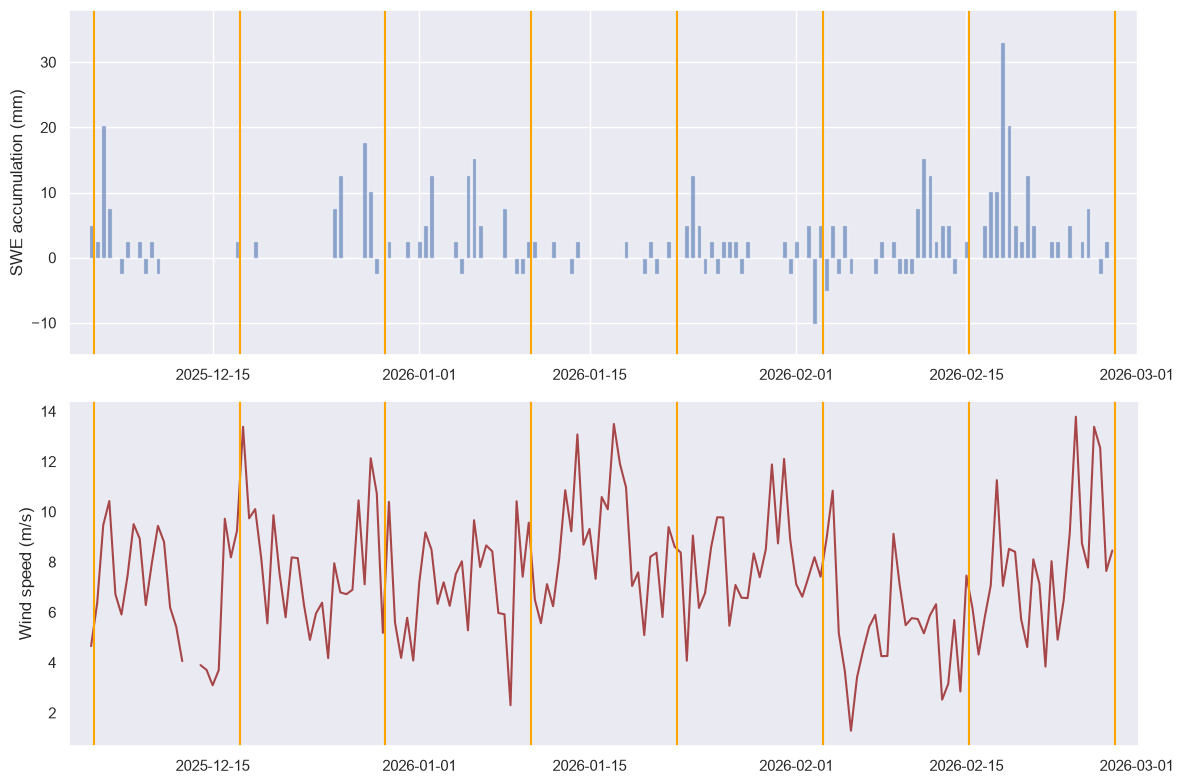

In [183]:
swe_6h = swe_dry.sel(station_name=swe_stns)['swe_accum'].mean(dim='station_id').resample(datetime=freq).sum()
wind_6h = wind_dry.sel(station_id=wind_stns).mean(dim='station_id').resample(datetime=freq).mean()
events = swe_6h['datetime'].values[(swe_6h > threshold).values]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
(ax, ax2) = axes

ax.bar(swe_6h['datetime'], swe_6h, edgecolor=None, alpha=0.6, width=0.4)
ax.set_ylabel('SWE accumulation (mm)')
ax.set_ylim((-15, 38))

ax2.plot(wind_6h['datetime'], wind_6h, c='darkred', alpha=0.7)
ax2.set_ylabel('Wind speed (m/s)')
ax2.grid(False)

[a.axvline(d, c='orange') for a in axes for d in unique_dates]

# for s, e in zip(starts, ends):
#     for t in events[(events >= s) & (events <= e)]:
#         [a.axvspan(t, min(t + np.timedelta64(24, 'h'), e), alpha=0.2) for a in axes]

ax.set_xlim((dry_starts[0] - pd.Timedelta(days=2), dry_ends[-1] + pd.Timedelta(days=2)))
ax2.set_xlim((dry_starts[0] - pd.Timedelta(days=2), dry_ends[-1] + pd.Timedelta(days=2)))

plt.tight_layout()
plt.show()

Idea: 
wind lowers coherence more on SW aspects than NE aspects. 

Save the zarrs. 

In [ ]:
wind.to_zarr(data_dir + 'stations/zarrs/wind.zarr', mode="w")
swe.to_zarr(data_dir + 'stations/zarrs/swe.zarr', mode="w")
xr.Dataset({'storm_index': storm_by_pair, 'snow_wind_mps': snow_wind_mps}).to_zarr(data_dir + 'nisar/zarrs/storm_pairs.zarr', mode="w")